In [15]:
import os
import sys

In [16]:
import json

with open("client_ip.json", "r") as f:
    client_ip = json.load(f)

In [17]:
import tensorflow as tf

In [18]:
print(tf.__version__)

2.19.0


In [21]:
batch_size = 128
features = 40
input_shape = (features,2)

In [22]:
import matplotlib.pyplot as plt
import numpy as np
WINDOW=40
def lstm_vector(ts1,sizes1,ts2,sizes2,voip=False):
    #determine direction
    if voip:
        src_ts = ts1
        src_sizes = sizes1
        dst_ts = ts2
        dst_sizes = sizes2
    else:
        if ts1[0]<ts2[0]:
            src_ts = ts1
            src_sizes = sizes1
            dst_ts = ts2
            dst_sizes = sizes2
        else:
            src_ts = ts2
            src_sizes = sizes2
            dst_ts = ts1
            dst_sizes = sizes1
    array = []
    j = 0 #src
    k = 0 #dst
    min_val = min(src_ts[0],dst_ts[0])
    length = len(src_ts)+len(dst_ts)
    for i in range(40):
        if j>=len(src_ts) and k>=len(dst_ts):
            break
        if j>=len(src_ts):
            array.append([round(dst_ts[k]-min_val,6),-dst_sizes[k]])
            k+=1
        elif k >= len(dst_ts):
            array.append([round(src_ts[j]-min_val,6),src_sizes[j]]) 
            j+=1
        elif src_ts[j]<=dst_ts[k]:
            array.append([round(src_ts[j]-min_val,6),src_sizes[j]]) 
            j+=1
        else:
            array.append([round(dst_ts[k]-min_val,6),-dst_sizes[k]])
            k+=1
    # for i in range(WINDOW-length):
    #      array.append([0,0])
    array = np.array(array)
    X = array.reshape(-1,2)
    return X

In [23]:
def check_strings_in_classname(classname):
    keywords = {
    "web": 0, "video": 1, "social": 2, "email": 3,"voip":4,"chat":5,"gaming":6,"docs":7
    }
    for keyword in keywords:
        if keyword in classname:
            return keywords[keyword] 
    return None

In [24]:
# check_path = os.path.join(checkpoint_dir, MODEL_NAME + 'pseudo_labeled_binary_lstm_acc.weights.h5')
# pipeline.named_steps['model'].load_weights(check_path) 

In [25]:
X_train = []
y_train = []

In [26]:
path2 = os.path.abspath('..')

In [27]:
import os
import csv
import tensorflow as tf

folder_path = path2+"/labeled_train"

In [28]:
import json
def traffic_csv_converter(file_path):
    X_train = []
    y_train = []
    with open(file_path, 'r') as csv_file:
        reader = csv.reader(csv_file)
        filename = os.path.splitext(os.path.basename(file_path))[0]
        flow_val = {}
        class_val = {}
        paired_keys = set()
        for i, row in enumerate(reader):
            class_name = row[0]
            src_ip = row[1]
            src_port = row[2]
            dst_ip = row[3]
            dst_port = row[4]
            length = int(row[7])
            ts = np.array(row[8:8+length], dtype=float)
            sizes = np.array(row[9+length:], dtype=int)
            key = (src_ip, src_port, dst_ip, dst_port)
            reverse_key = (dst_ip, dst_port, src_ip, src_port)
            if reverse_key in flow_val:
                # Found the reverse flow
                opposite_ts, opposite_sizes = flow_val.pop(reverse_key)
                paired_keys.add(key)
                paired_keys.add(reverse_key)
                if len(opposite_ts) + len(ts) < 40: #flow too small
                    continue
                if "voip" in file_path and class_name =="voip":
                    if reverse_key[0] in client_ip:
                        src_ts, src_sizes = opposite_ts, opposite_sizes
                        dst_ts, dst_sizes = ts, sizes
                    else:
                        src_ts, src_sizes = ts, sizes
                        dst_ts, dst_sizes = opposite_ts, opposite_sizes
                    x = lstm_vector(src_ts, src_sizes, dst_ts, dst_sizes,True)
                    v = seq_50(src_ts, src_sizes, dst_ts, dst_sizes)
                else:
                    src_ts, src_sizes = opposite_ts, opposite_sizes
                    dst_ts, dst_sizes = ts, sizes
                    x = lstm_vector(src_ts, src_sizes, dst_ts, dst_sizes)
                    v = seq_50(src_ts, src_sizes, dst_ts, dst_sizes)
                if "voip" in file_path and class_name == "voip":
                    voip.append(v)
                    y_train.append(7)
                elif "gaming" in file_path:
                    gaming.append(v)
                    y_train.append(8)
                elif class_name == "web":
                    web.append(v)
                    y_train.append(0)
                elif class_name == "video":
                    video.append(v)
                    y_train.append(1)
                elif class_name == "social":
                    social.append(v)
                    y_train.append(2)
                elif class_name == "email":
                    email.append(v)
                    y_train.append(3)
                elif class_name == "doc":
                    doc.append(v)
                    y_train.append(4)
                elif class_name == "microsoft":
                    microsoft.append(v)
                    y_train.append(5)
                elif class_name == "chat":
                    chat.append(v)
                    y_train.append(6)
                else: #background_flow
                    background.append(v)
                    y_train.append(9)
                X_train.append(x)
            else:
                # Save forward direction flow
                flow_val[key] = (ts, sizes)
                class_val[key] = class_name
    for key, value in flow_val.items():
        if len(value[0]) >= 40:
            if "voip" in file_path:
                ts = value[0][:40]
                sizes = value[1][:40]
                if key[0] in client_ip:
                    sizes = value[1][:40]
                else:
                    sizes = -value[1][:40]
                v = np.stack((ts, sizes), axis=1)
                X_train.append(v)
                if class_val[key] == "voip": #if the flow is unique
                    y_train.append(7)
                else:
                    y_train.append(9) #if the flow is background
                
                ts = value[0][:50]
                if key[0] in client_ip:
                    sizes = value[1][:50]
                else:
                    sizes = -value[1][:50]
                if len(ts)<50:
                    pad = 50 - len(ts)
                    ts    = np.pad(ts,    (0, pad), mode="constant", constant_values=0)
                    sizes = np.pad(sizes, (0, pad), mode="constant", constant_values=0)
                    
                v = np.stack((ts, sizes), axis=1)
                if class_val[key] == "voip":
                    voip.append(v)
            elif "gaming" in file_path:
                ts = value[0][:40]
                sizes = value[1][:40]
                v = np.stack((ts, sizes), axis=1)
                X_train.append(v)
                y_train.append(8)
                
                ts = value[0][:50]
                sizes = value[1][:50]
                if len(ts)<50:
                    pad = 50 - len(ts)
                    ts    = np.pad(ts,    (0, pad), mode="constant", constant_values=0)
                    sizes = np.pad(sizes, (0, pad), mode="constant", constant_values=0)
                v = np.stack((ts, sizes), axis=1)
                gaming.append(v)
            
            
    return X_train, y_train
def iterate_over_files_in_directory(directory):
    for file_name in os.listdir(directory):
        if file_name.endswith(".csv"):  # You can adjust the file extension if needed
            file_path = os.path.join(directory, file_name)
            yield file_path


In [14]:
docs_path = folder_path + "/docs"
for file_path in iterate_over_files_in_directory(docs_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
web_path = folder_path + "/web"
for file_path in iterate_over_files_in_directory(web_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
chat_path = folder_path + "/chat"
for file_path in iterate_over_files_in_directory(chat_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
social_path = folder_path + "/social"
for file_path in iterate_over_files_in_directory(social_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
video_path = folder_path + "/video"
for file_path in iterate_over_files_in_directory(video_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
voip_path = folder_path + "/voip"
for file_path in iterate_over_files_in_directory(voip_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
gaming_path = folder_path + "/gaming"
for file_path in iterate_over_files_in_directory(gaming_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
email_path = folder_path + "/email"
for file_path in iterate_over_files_in_directory(email_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)

Unidirectional flow: ('152.23.212.204', '5353', '224.0.0.251', '5353'), length = 61
/nas/longleaf/home/paulchoi/labeled_train/voip/f_voip_25_labeled.csv
Unidirectional flow: ('fe80::14b9:6d91:1113:abb6', '5353', 'ff02::fb', '5353'), length = 61
/nas/longleaf/home/paulchoi/labeled_train/voip/f_voip_25_labeled.csv
Unidirectional flow: ('152.23.212.204', '5353', '224.0.0.251', '5353'), length = 46
/nas/longleaf/home/paulchoi/labeled_train/voip/f_voip_24_labeled.csv
Unidirectional flow: ('fe80::14b9:6d91:1113:abb6', '5353', 'ff02::fb', '5353'), length = 46
/nas/longleaf/home/paulchoi/labeled_train/voip/f_voip_24_labeled.csv
Unidirectional flow: ('152.23.212.204', '5353', '224.0.0.251', '5353'), length = 106
/nas/longleaf/home/paulchoi/labeled_train/voip/f_voip_22_labeled.csv
Unidirectional flow: ('fe80::14b9:6d91:1113:abb6', '5353', 'ff02::fb', '5353'), length = 106
/nas/longleaf/home/paulchoi/labeled_train/voip/f_voip_22_labeled.csv
Unidirectional flow: ('152.23.212.204', '5353', '224.0.0

In [15]:
import numpy as np

In [16]:
X_dataset = np.array(X_train)

In [17]:
y_dataset = np.array(y_train)

In [18]:
from collections import Counter
counter = Counter(y_dataset)
counts = [counter.get(i, 0) for i in range(10)]

In [19]:
max_val = max(counts)

In [20]:
max_val

23649

In [21]:
counts

[2697, 466, 792, 113, 116, 239, 54, 1175, 1006, 23649]

In [29]:
def translation(X):
    arrival_times = X
    n,time_steps,features = arrival_times.shape
    for i in range(n):
        threshold_indices = [2,4,6,8,10] 
        max_n =np.random.choice(threshold_indices) 
        n = np.random.randint(1, max_n + 1)  # Shift 1 to `max_n` packets
        t = np.random.randint(0, 40) 
        direction = np.random.choice(['left', 'right'])
        if direction == 'left':
            total_length = arrival_times.shape[1]
            start_index = t-n
            if start_index < 0: 
                valid_portion = arrival_times[i, t - start_index:50]
                assigned_value = valid_portion.shape[0]
                arrival_times[i, 0:assigned_value] = valid_portion
                arrival_times[i, assigned_value+1:] = 0 
            else:
                valid_portion = arrival_times[i, t:(50)]
                assigned_value = arrival_times[i, start_index:50].shape
                zeros = np.zeros((assigned_value[0]-valid_portion.shape[0],2))
                arrival_times[i, start_index:50] = np.concatenate((valid_portion, zeros))  # bounded to the right by 50
            
        else:
            t_val = arrival_times[i, t] 
            last_index = min(t + n, 40) 
            first_val = min(last_index + n, 40)  
            num_to_shift = last_index - t  
            available_space = 40 - first_val 
            if num_to_shift > 0:
                shift_amount = min(num_to_shift, available_space)
                arrival_times[i, first_val:first_val + shift_amount] = arrival_times[i, t:t + shift_amount]
            arrival_times[i, t:last_index] = t_val
    return arrival_times

In [ ]:
for i in range(9):
    if i == 0:
        sample = web
    elif i == 1:
        sample = video
    elif i == 2:
        sample = social
    elif i == 3:
        sample = email
    elif i == 4:
        sample = doc
    elif i == 5:
        sample = microsoft
    elif i == 6:
        sample = chat
    elif i == 7:
        sample = voip
    elif i == 8:
        sample = gaming
    indices = tf.range(sample.shape[0])
    value = len(sample)
    sampled_indices = np.random.choice(indices, max_val-value, replace=True)
    sampled_X = sample[sampled_indices]
    augmented = translation(sampled_X)
    augmented = augmented[:, :40, :]
    X_dataset = np.vstack((X_dataset,augmented))
    y = np.array([i]*(max_val-value))
    y_dataset = np.concatenate((y_dataset,y))

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_dataset, y_dataset, test_size=0.2, random_state=42)

In [ ]:
np.save('X_train.npy', X_train)
np.save('y_train.npy', y_train)
np.save('X_val.npy', X_val)
np.save('y_val.npy', y_val)
# X_train = np.load('X_train.npy')
# y_train = np.load('y_train.npy')
# X_val = np.load('X_val.npy')
# y_val = np.load('y_val.npy')

In [30]:
from keras.utils import to_categorical

In [ ]:
y_train = to_categorical(y_train, num_classes=10)
y_val = to_categorical(y_val, num_classes=10)

In [31]:
num_classes = 10

In [32]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras.callbacks import TensorBoard, ModelCheckpoint
from keras.models import Sequential,Model
from keras.layers import InputLayer,Conv1D, MaxPooling1D, Flatten, Dense, Dropout,LSTM,BatchNormalization,Bidirectional,LayerNormalization
from keras import backend as K
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from keras.metrics import top_k_categorical_accuracy
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow.keras.backend as K
import tensorflow as tf
from tensorflow.keras import layers, models
path = os.path.abspath('')


def precision(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    return precision

def recall(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    recall = true_positives / (possible_positives + K.epsilon())
    return recall

def f1_score(y_true, y_pred):
    prec = precision(y_true, y_pred)
    rec = recall(y_true, y_pred)
    return 2 * ((prec * rec) / (prec + rec))

# def top_2_categorical_accuracy(y_true, y_pred):
#     return top_k_categorical_accuracy(y_true, y_pred, k=2)

# Custom transformer to transpose data

# Set the ratio for the train-test split

def build_lstm_classifier(input_shape, num_classes, 
                          encoder_units=(128, 64), 
                          projection_dim=64, 
                          dropout_rate=0.1):
    """
    Builds an LSTM-based classifier.

    Args:
      input_shape: tuple, e.g. (timesteps, features)
      num_classes: int, number of target classes
      encoder_units: tuple of two ints, the hidden sizes of the two Bi‑LSTM layers
      projection_dim: int, size of the intermediate dense ('representation') layer
      dropout_rate: float, dropout after the second LSTM

    Returns:
      A tf.keras.Model ready for compilation.
    """
    inputs = layers.Input(shape=input_shape, name="input_sequence")

    # First Bi‑LSTM block
    x = layers.Bidirectional(
        layers.LSTM(encoder_units[0], return_sequences=True),
        name="bi_lstm_1"
    )(inputs)
    x = layers.LayerNormalization(name="ln_1")(x)

    # Second Bi‑LSTM block
    x = layers.Bidirectional(
        layers.LSTM(encoder_units[1], return_sequences=False),
        name="bi_lstm_2"
    )(x)
    x = layers.LayerNormalization(name="ln_2")(x)
    x = layers.Dropout(dropout_rate, name="dropout")(x)

    # Bottleneck / projection
    h = layers.Dense(
        projection_dim, 
        activation="gelu", 
        name="representation"
    )(x)

    # Classification head
    outputs = layers.Dense(
        num_classes, 
        activation="softmax", 
        name="classifier"
    )(h)

    return models.Model(inputs, outputs, name="lstm_classifier")

# Example usage:
timesteps, features = 40, 2       # adjust to your data
num_classes = 10                 # set to your number of classes
model = build_lstm_classifier(
    input_shape=(timesteps, features),
    num_classes=num_classes
)
model.compile(loss='categorical_crossentropy',
                                      optimizer='adam',
                                      metrics=['accuracy', f1_score, precision, recall])

# Set up callbacks
checkpoint_dir = os.path.abspath('')+"/tensorboard"
log_dir = os.path.abspath('') + "/log"
MODEL_NAME = "checkpoint"
check_path = os.path.join(checkpoint_dir, MODEL_NAME + 'lstm_loss.weights.h5')
tensorboard = TensorBoard(log_dir='./Graph', histogram_freq=1, write_graph=True,
                          write_images=True)
checkpointer_loss = ModelCheckpoint(filepath=check_path, verbose=1, save_best_only=True,
                                     save_weights_only=True)
checkpointer_acc = ModelCheckpoint(monitor='val_f1_score', filepath= os.path.join(checkpoint_dir, MODEL_NAME + 'lstm_acc.weights.h5'), verbose=1,
                                    save_best_only=True, save_weights_only=True,mode='max')
tensorboard.set_model(model)

early_stopping = EarlyStopping(monitor='val_f1_score', patience=50, restore_best_weights=True,mode='max')



W0000 00:00:1753971294.978961  521072 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [ ]:
model.fit(X_train, y_train, epochs=500, batch_size=batch_size, callbacks=[early_stopping,tensorboard, checkpointer_loss, checkpointer_acc],
         validation_data=(X_val, y_val))

Epoch 1/500
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.6737 - f1_score: nan - loss: 0.9097 - precision: 0.8294 - recall: 0.5548
Epoch 1: val_loss improved from inf to 0.27355, saving model to /nas/longleaf/home/paulchoi/2stage/tensorboard/checkpointlstm_loss.weights.h5

Epoch 1: val_f1_score improved from -inf to 0.89857, saving model to /nas/longleaf/home/paulchoi/2stage/tensorboard/checkpointlstm_acc.weights.h5
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 316s 204ms/step - accuracy: 0.6738 - f1_score: nan - loss: 0.9095 - precision: 0.8295 - recall: 0.5549 - val_accuracy: 0.8981 - val_f1_score: 0.8986 - val_loss: 0.2736 - val_precision: 0.9163 - val_recall: 0.8816
Epoch 2/500
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.9080 - f1_score: 0.9081 - loss: 0.2574 - precision: 0.9235 - recall: 0.8934
Epoch 2: val_loss improved from 0.27355 to 0.16225, saving model to /nas/longleaf/home/paulchoi/2stage/tensorboard/checkpointlstm_loss.weights.h5

Epoch 2: val_f1_score improve

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



1534/1534 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.9789 - f1_score: 0.9791 - loss: 0.0609 - precision: 0.9805 - recall: 0.9777
Epoch 10: val_loss improved from 0.08515 to 0.08166, saving model to /nas/longleaf/home/paulchoi/2stage/tensorboard/checkpointlstm_loss.weights.h5

Epoch 10: val_f1_score improved from 0.97202 to 0.97314, saving model to /nas/longleaf/home/paulchoi/2stage/tensorboard/checkpointlstm_acc.weights.h5
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 297s 194ms/step - accuracy: 0.9789 - f1_score: 0.9791 - loss: 0.0609 - precision: 0.9805 - recall: 0.9777 - val_accuracy: 0.9729 - val_f1_score: 0.9731 - val_loss: 0.0817 - val_precision: 0.9744 - val_recall: 0.9719
Epoch 11/500
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.9800 - f1_score: 0.9801 - loss: 0.0571 - precision: 0.9812 - recall: 0.9791
Epoch 11: val_loss improved from 0.08166 to 0.07193, saving model to /nas/longleaf/home/paulchoi/2stage/tensorboard/checkpointlstm_loss.weights.h5

Epoch 11: val_f1_score i

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



1056/1534 ━━━━━━━━━━━━━━━━━━━━ 1:26 181ms/step - accuracy: 0.9889 - f1_score: 0.9890 - loss: 0.0319 - precision: 0.9895 - recall: 0.9885
Epoch 18: val_loss did not improve from 0.06087

Epoch 18: val_f1_score did not improve from 0.98110
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 297s 194ms/step - accuracy: 0.9886 - f1_score: 0.9886 - loss: 0.0330 - precision: 0.9891 - recall: 0.9881 - val_accuracy: 0.9792 - val_f1_score: 0.9793 - val_loss: 0.0669 - val_precision: 0.9799 - val_recall: 0.9787
Epoch 19/500
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.9886 - f1_score: 0.9886 - loss: 0.0331 - precision: 0.9890 - recall: 0.9881
Epoch 19: val_loss did not improve from 0.06087

Epoch 19: val_f1_score did not improve from 0.98110
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 296s 193ms/step - accuracy: 0.9885 - f1_score: 0.9886 - loss: 0.0331 - precision: 0.9890 - recall: 0.9881 - val_accuracy: 0.9803 - val_f1_score: 0.9803 - val_loss: 0.0679 - val_precision: 0.9810 - val_recall: 0.9796
Epoch 20/500
1458/1

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



 960/1534 ━━━━━━━━━━━━━━━━━━━━ 1:43 180ms/step - accuracy: 0.9900 - f1_score: 0.9900 - loss: 0.0293 - precision: 0.9904 - recall: 0.9896

In [21]:
# model = pipeline.named_steps['model']
# model.build(input_shape=(None, 50, 2)) 

In [36]:
from tensorflow.keras import Input
check_path = os.path.join(checkpoint_dir, MODEL_NAME + 'lstm_acc.weights.h5')
input_shape = (40, 2)
model.load_weights(check_path)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
# weighted_accuracy = round(weighted_accuracy(y_test_categorical, y_pred, flow_sizes), 2)
macro_f1 = round(f1_score(y_test_categorical, y_pred, average='macro'), 2)
accuracy = round(accuracy_score(y_test_categorical, y_pred), 2)
average_f1 = round(f1_score(y_test_categorical, y_pred, average='weighted'), 2)
# precision = precision_score(y_test_categorical, y_pred, average=None)
# recall = recall_score(y_test_categorical, y_pred, average=None)
# f1 = f1_score(y_test_categorical, y_pred, average=None)
conf_matrix = confusion_matrix(y_test_categorical, y_pred)

# Print or use the evaluation metrics as needed
# print(f'Weighted Average Accuracy: {weighted_accuracy}')
print(f'Macro Average F1 Score: {macro_f1}')
print(f'Accuracy: {accuracy}')
print(f'Weighted Average F1 Score: {average_f1}')
# print(f'Precision: {precision}')
# print(f'Recall: {recall}')
# print(f'F1 Score: {f1}')
# print(f'Confusion Matrix:\n{conf_matrix}')

In [ ]:
y_pred_prob = model.predict(X_val)
y_pred = np.argmax(y_pred_prob, axis=1)
y_test=np.array(y_val)
y_test_categorical = y_test

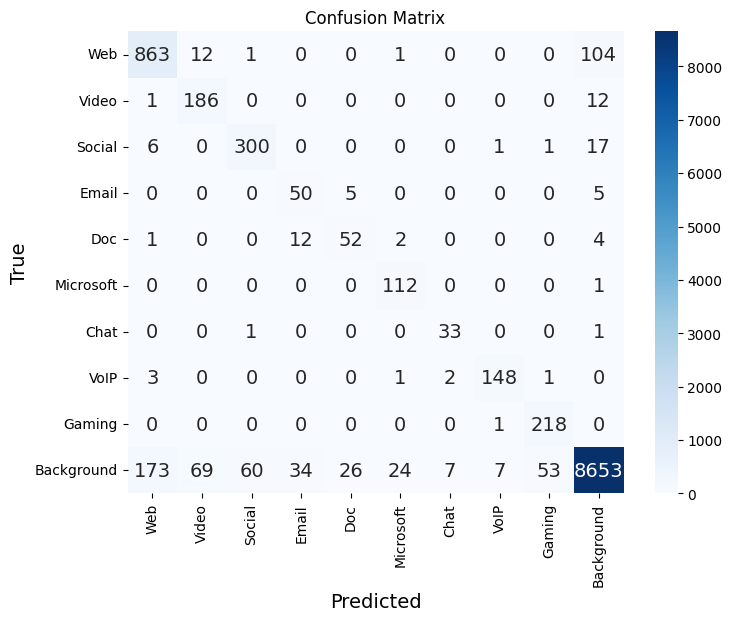

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix_percentage = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

class_names = ["Web","Video","Social","Email","Doc","Microsoft","Chat","VoIP","Gaming","Background"]
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names,annot_kws={"size": 14})
# ax = sns.heatmap(conf_matrix_percentage, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
# for t in ax.texts: t.set_text(t.get_text() + " %")
plt.xlabel('Predicted', fontsize=14)
plt.ylabel('True', fontsize=14)
plt.title('Confusion Matrix')
plt.savefig('40 >40 confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
X_test = []
y_test = []
domain_name = []

In [21]:
import csv
def test_traffic_csv_converter(file_path):
    X_train = []
    y_train = []
    with open(file_path, 'r') as csv_file:
        reader = csv.reader(csv_file)
        filename = os.path.splitext(os.path.basename(file_path))[0]
        flow_val = {}
        class_val = {}
        paired_keys = set()
        for i, row in enumerate(reader):
            domainname = row[0]
            class_name = row[1]
            src_ip = row[2]
            src_port = row[3]
            dst_ip = row[4]
            dst_port = row[5]
            length = int(row[8])
            ts = np.array(row[9:9+length], dtype=float)
            sizes = np.array(row[10+length:], dtype=int)
            key = (src_ip, src_port, dst_ip, dst_port)
            reverse_key = (dst_ip, dst_port, src_ip, src_port)
            if reverse_key in flow_val:
                # Found the reverse flow
                opposite_ts, opposite_sizes = flow_val.pop(reverse_key)
                paired_keys.add(key)
                paired_keys.add(reverse_key)
                if len(opposite_ts) + len(ts) < 40: #flow too small
                    continue
                if "voip" in file_path and class_name =="voip":
                    if reverse_key[0] in client_ip:
                        src_ts, src_sizes = opposite_ts, opposite_sizes
                        dst_ts, dst_sizes = ts, sizes
                    else:
                        src_ts, src_sizes = ts, sizes
                        dst_ts, dst_sizes = opposite_ts, opposite_sizes
                    x = lstm_vector(src_ts, src_sizes, dst_ts, dst_sizes,True)
                else:
                    src_ts, src_sizes = opposite_ts, opposite_sizes
                    dst_ts, dst_sizes = ts, sizes
                    x = lstm_vector(src_ts, src_sizes, dst_ts, dst_sizes)
                if "voip" in file_path and class_name == "voip":
                    y_train.append(7)
                elif "gaming" in file_path:
                    y_train.append(8)
                elif class_name == "web":
                    y_train.append(0)
                elif class_name == "video":
                    y_train.append(1)
                elif class_name == "social":
                    y_train.append(2)
                elif class_name == "email":
                    y_train.append(3)
                elif class_name == "doc":
                    y_train.append(4)
                elif class_name == "microsoft":
                    y_train.append(5)
                elif class_name == "chat":
                    y_train.append(6)
                else: #background_flow
                    y_train.append(9)
                X_train.append(x)
                domain_name.append(domainname)
            else:
                # Save forward direction flow
                flow_val[key] = (ts, sizes)
                class_val[key] = class_name
    for key, value in flow_val.items():
        if key[1] == "5353":
            continue
        if len(value[0]) >= 40:
            if "voip" in file_path:
                ts = value[0][:40]
                sizes = value[1][:40]
                if key[0] in client_ip:
                    sizes = value[1][:40]
                else:
                    sizes = -value[1][:40]
                v = np.stack((ts, sizes), axis=1)
                # X_train.append(v)
                if class_val[key] == "voip": #if the flow is unique
                    X_train.append(v)
                    y_train.append(7)
                    domain_name.append("voip")

                else:
                    X_train.append(v)
                    y_train.append(9) #if the flow is background
                    domain_name.append("background")
            elif "gaming" in file_path:
                ts = value[0][:40]
                sizes = value[1][:40]
                v = np.stack((ts, sizes), axis=1)
                X_train.append(v)
                y_train.append(8)
                domain_name.append("gaming")
    return X_train, y_train


In [22]:
folder_path = os.path.abspath('..')+"/domain_labeled_test"
docs_path = folder_path + "/docs"
for file_path in iterate_over_files_in_directory(docs_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
web_path = folder_path + "/web"
for file_path in iterate_over_files_in_directory(web_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
chat_path = folder_path + "/chat"
for file_path in iterate_over_files_in_directory(chat_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
social_path = folder_path + "/social"
for file_path in iterate_over_files_in_directory(social_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
video_path = folder_path + "/video"
for file_path in iterate_over_files_in_directory(video_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
voip_path = folder_path + "/voip"
for file_path in iterate_over_files_in_directory(voip_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
gaming_path = folder_path + "/gaming"
for file_path in iterate_over_files_in_directory(gaming_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
email_path = folder_path + "/email"
for file_path in iterate_over_files_in_directory(email_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)

In [23]:
X_test = np.array(X_test)

In [24]:
y_test=np.array(y_test)
y_test.shape

(11264,)

In [40]:
y_pred_prob = model.predict(X_train)
y_pred = np.argmax(y_pred_prob, axis=1)

1534/1534 ━━━━━━━━━━━━━━━━━━━━ 45s 29ms/step


In [46]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
# weighted_accuracy = round(weighted_accuracy(y_test_categorical, y_pred, flow_sizes), 2)
macro_f1 = round(f1_score(y_val, y_pred, average='macro'), 2)
accuracy = round(accuracy_score(y_val, y_pred), 2)
average_f1 = round(f1_score(y_val, y_pred, average='weighted'), 2)
# precision = precision_score(y_test_categorical, y_pred, average=None)
# recall = recall_score(y_test_categorical, y_pred, average=None)
# f1 = f1_score(y_test_categorical, y_pred, average=None)
conf_matrix = confusion_matrix(y_val, y_pred)

# Print or use the evaluation metrics as needed
# print(f'Weighted Average Accuracy: {weighted_accuracy}')
print(f'Macro Average F1 Score: {macro_f1}')
print(f'Accuracy: {accuracy}')
print(f'Weighted Average F1 Score: {average_f1}')
# print(f'Precision: {precision}')
# print(f'Recall: {recall}')
# print(f'F1 Score: {f1}')
# print(f'Confusion Matrix:\n{conf_matrix}')

Macro Average F1 Score: 0.99
Accuracy: 0.99
Weighted Average F1 Score: 0.99


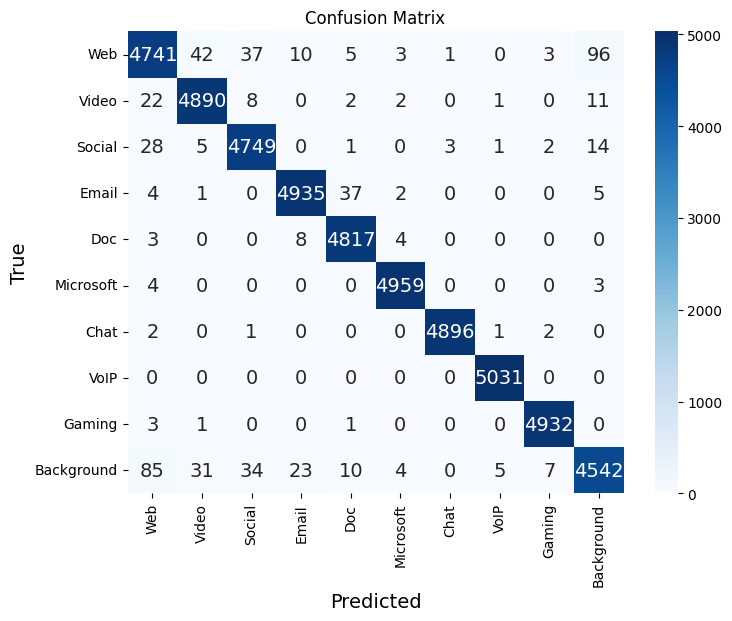

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix_percentage = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

class_names = ["Web","Video","Social","Email","Doc","Microsoft","Chat","VoIP","Gaming","Background"]
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names,annot_kws={"size": 14})
# ax = sns.heatmap(conf_matrix_percentage, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
# for t in ax.texts: t.set_text(t.get_text() + " %")
plt.xlabel('Predicted', fontsize=14)
plt.ylabel('True', fontsize=14)
plt.title('Confusion Matrix')
plt.savefig('40 >40 confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
y_test=np.array(y_test)
y_test_categorical = y_test

In [ ]:
conf_matrix_percentage = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

conf_matrix_percentage = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

class_names = ["Web","Video","Social","Email","Doc","Microsoft","Chat","VoIP","Gaming","Background"]

# Plot confusion matrix
plt.figure(figsize=(8, 6))
annot_kws = {"size": 11}
# sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
ax = sns.heatmap(conf_matrix_percentage, annot=True, fmt='.1f', cmap='Blues', xticklabels=class_names, yticklabels=class_names,annot_kws=annot_kws)
for t in ax.texts: t.set_text(t.get_text() + " %")
plt.xlabel('Predicted', fontsize=14)  
plt.ylabel('True', fontsize=14)
plt.title('Confusion Matrix')
plt.savefig('40 >40 confusion_matrixpercent.png', dpi=300, bbox_inches='tight')
plt.show()

In [44]:
def weighted_accuracy(y_true, y_pred, flow_sizes):
    total_flow_size = sum(flow_sizes)
    weighted_acc = 0
    for i, flow_size in enumerate(flow_sizes):
        if y_true[i] == y_pred[i]:
            prediction = 1
        else:
            prediction = 0
        weighted_acc += flow_size * prediction
    weighted_acc /= total_flow_size
    
    return weighted_acc

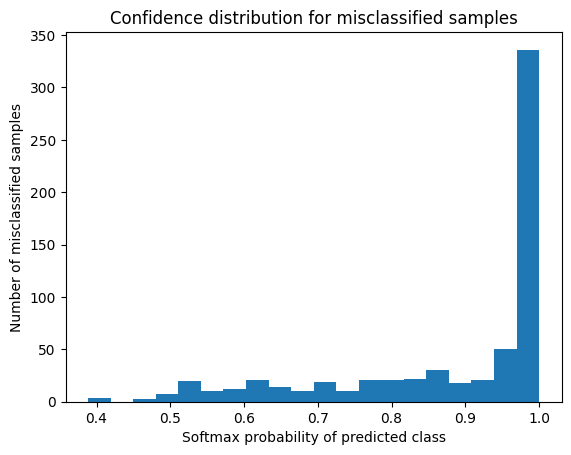

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# mask for misclassified samples
mask = (y_pred != y_test)

# pick out the probability that the model assigned to its (wrong) prediction
mis_probs = y_pred_prob[mask, y_pred[mask]]

# plot a histogram of those confidences
plt.figure()
plt.hist(mis_probs, bins=20)
plt.xlabel('Softmax probability of predicted class')
plt.ylabel('Number of misclassified samples')
plt.title('Confidence distribution for misclassified samples')
plt.show()

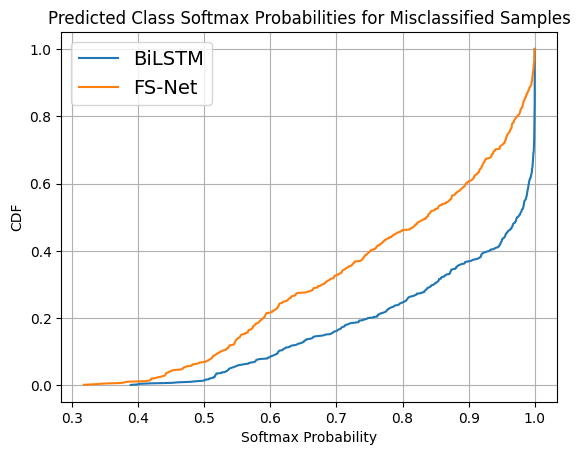

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Select only the misclassified samples
mask = (y_pred != y_test)

# 2) Grab the softmax score assigned to the (wrong) predicted class
mis_probs = y_pred_prob[mask, y_pred[mask]]

# 3) Sort and build the CDF
sorted_probs = np.sort(mis_probs)
sorted_probs2 = np.load("fsnet_sorted_probs.npy")
cdf = np.arange(1, len(sorted_probs) + 1) / len(sorted_probs)
cdf2 = np.arange(1, len(sorted_probs2) + 1) / len(sorted_probs2)
# 4) Plot
plt.figure()
plt.plot(sorted_probs,  cdf,  label='BiLSTM')
plt.plot(sorted_probs2, cdf2, label='FS-Net')
plt.xlabel('Softmax Probability')
plt.ylabel('CDF')
plt.legend(fontsize=14)   
plt.grid(True) 
plt.title('Predicted Class Softmax Probabilities for Misclassified Samples')
plt.savefig(
    'cdf_misclass_probs.png',   # filename (use .pdf or .svg if you like)
    dpi=300,                    # resolution in dots-per-inch
    bbox_inches='tight'         # trim extra whitespace
)
plt.show()

In [34]:
y_pred = np.argmax(y_pred_prob, axis=1)  # shape (N,)

# — Step 1: Compute the “max confidence” per sample — #
# This finds, for each sample i, the highest softmax‐score across all classes.
confidences = np.max(y_pred_prob, axis=1)  # shape: (N,)

# — Step 2: Build a mask for “keep only if max confidence ≥ 0.9” — #
mask_high_conf = confidences >= 0.90  # shape: (N,), dtype=bool

# — Step 3: Filter your arrays by that mask — #
# If you want to keep only rows with confidence ≥ 0.9 in y_pred_prob:
y_pred_prob_filtered = y_pred_prob[mask_high_conf]  # shape: (__ , C)

# If you also want to keep only those predicted‐class indices:
y_pred_filtered = y_pred[mask_high_conf]

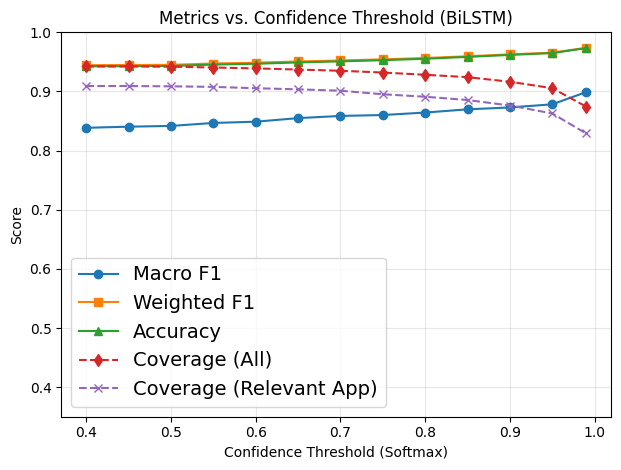

In [40]:
conf  = y_pred_prob.max(axis=1)
pred  = y_pred_prob.argmax(axis=1)
correct = (pred == y_test)

thresholds = np.array([
    0.40, 0.45, 0.50, 0.55, 0.60,
    0.65, 0.70, 0.75, 0.80, 0.85,
    0.90, 0.95, 0.99
])

macro_f1, weighted_f1, acc = [], [], []
coverage_all, coverage_true_non9 = [], []

non9_true = (y_test != 9)
total = len(y_test)
total_non9 = non9_true.sum()

for t in thresholds:
    m = conf >= t                      # keep mask
    # — new coverage definitions — #
    cov_all = (m & correct).sum() / total
    cov_non9 = (m & non9_true & correct).sum() / total_non9

    if m.sum() == 0:
        macro_f1.append(np.nan)
        weighted_f1.append(np.nan)
        acc.append(np.nan)
    else:
        yt, yp = y_test[m], pred[m]
        acc.append(accuracy_score(yt, yp))
        macro_f1.append(f1_score(yt, yp, average='macro'))
        weighted_f1.append(f1_score(yt, yp, average='weighted'))

    coverage_all.append(cov_all)
    coverage_true_non9.append(cov_non9)

# Plot
plt.figure()
plt.plot(thresholds, macro_f1,    marker='o', label='Macro F1')
plt.plot(thresholds, weighted_f1, marker='s', label='Weighted F1')
plt.plot(thresholds, acc,         marker='^', label='Accuracy')
plt.plot(thresholds, coverage_all,        marker='d', linestyle='--', label='Coverage (All)')
plt.plot(thresholds, coverage_true_non9,  marker='x', linestyle='--', label='Coverage (Relevant App)')
plt.xlabel('Confidence Threshold (Softmax)')
plt.ylabel('Score')
plt.title('Metrics vs. Confidence Threshold (BiLSTM)')
plt.legend(loc='lower left',fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.ylim(0.35, 1.0)
plt.savefig(
    'bilstm_metrics.png',   # filename (use .pdf or .svg if you like)
    dpi=300,                    # resolution in dots-per-inch
    bbox_inches='tight'         # trim extra whitespace
)
plt.show()

In [33]:
df = pd.DataFrame({
    'Threshold':               thresholds,
    'Macro F1':                macro_f1,
    'Weighted F1':             weighted_f1,
    'Accuracy':                acc,
    'Coverage (All)':          coverage_all,
    'Coverage (Relevant App)': coverage_true_non9
})

In [34]:
df

,Threshold,Macro F1,Weighted F1,Accuracy,Coverage (All),Coverage (Relevant App)
0,0.40,0.838576,0.944548,0.942550,0.942383,0.909175
1,0.45,0.840455,0.944689,0.942712,0.942294,0.909175
2,0.50,0.841738,0.945040,0.943111,0.941939,0.908712
3,0.55,0.846754,0.947272,0.945471,0.940518,0.907785
4,0.60,0.848904,0.948590,0.946827,0.939009,0.905468
5,0.65,0.854926,0.950735,0.949105,0.937056,0.903614
6,0.70,0.858613,0.952396,0.950885,0.935014,0.901297
7,0.75,0.860175,0.954313,0.952891,0.931996,0.895273
8,0.80,0.864333,0.956568,0.955322,0.928267,0.891103
9,0.85,0.869805,0.959525,0.958475,0.924183,0.885542


In [51]:
y_test_filtered = y_test[mask_high_conf]
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
# weighted_accuracy = round(weighted_accuracy(y_test_categorical, y_pred, flow_sizes), 2)
macro_f1 = round(f1_score(y_test_filtered, y_pred_filtered, average='macro'), 2)
accuracy = round(accuracy_score(y_test_filtered, y_pred_filtered), 2)
average_f1 = round(f1_score(y_test_filtered, y_pred_filtered, average='weighted'), 2)
# precision = precision_score(y_test_categorical, y_pred, average=None)
# recall = recall_score(y_test_categorical, y_pred, average=None)
# f1 = f1_score(y_test_categorical, y_pred, average=None)
conf_matrix = confusion_matrix(y_test_filtered, y_pred_filtered)

# Print or use the evaluation metrics as needed
# print(f'Weighted Average Accuracy: {weighted_accuracy}')
print(f'Macro Average F1 Score: {macro_f1}')
print(f'Accuracy: {accuracy}')
print(f'Weighted Average F1 Score: {average_f1}')
# print(f'Precision: {precision}')
# print(f'Recall: {recall}')
# print(f'F1 Score: {f1}')
# print(f'Confusion Matrix:\n{conf_matrix}')

Macro Average F1 Score: 0.87
Accuracy: 0.96
Weighted Average F1 Score: 0.96


In [42]:
indices = np.where((y_test!=y_pred))[0]

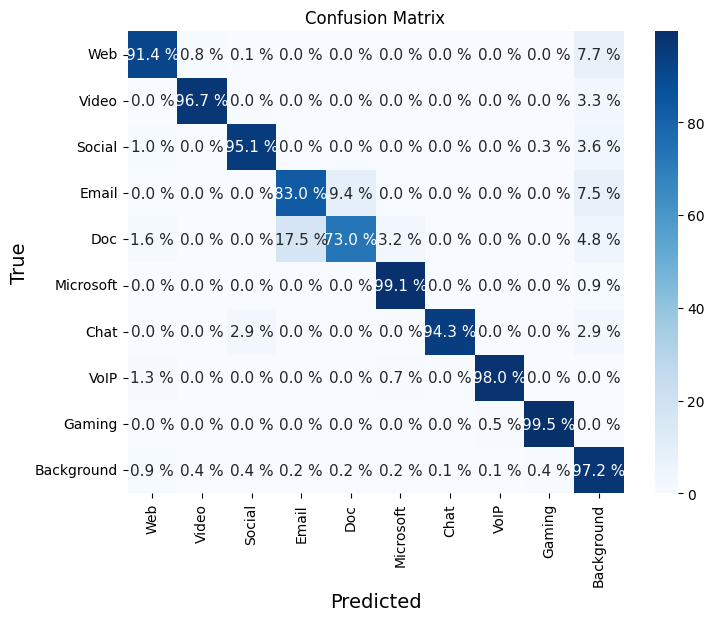

In [43]:
conf_matrix_percentage = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

conf_matrix_percentage = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

class_names = ["Web","Video","Social","Email","Doc","Microsoft","Chat","VoIP","Gaming","Background"]

# Plot confusion matrix
plt.figure(figsize=(8, 6))
annot_kws = {"size": 11}
# sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
ax = sns.heatmap(conf_matrix_percentage, annot=True, fmt='.1f', cmap='Blues', xticklabels=class_names, yticklabels=class_names,annot_kws=annot_kws)
for t in ax.texts: t.set_text(t.get_text() + " %")
plt.xlabel('Predicted', fontsize=14)  
plt.ylabel('True', fontsize=14)
plt.title('Confusion Matrix')
plt.savefig('40 >40 confusion_matrixpercent.png', dpi=300, bbox_inches='tight')
plt.show()